<a href="https://colab.research.google.com/github/ngyxntthaoo/IS6404.CH201-Phan-tich-du-lieu-nang-cao/blob/main/Lab04c_Lec06_TimeSeries_ML_Forecasting_PTDL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 4c (Lec06): Time Series Machine Learning - Forecasting
**Course:** IS6404 - Advanced Data Analysis, UIT, VNUHCM  
**Student:** Nguyễn Thanh Thảo - 250104025

---

Notebook này minh họa pipeline chuẩn cho **time series forecasting** theo hướng thực dụng:

- Baseline cổ điển: naive / seasonal naive / ARIMA
- ML-based forecasting: lag features + ML model
- So sánh mô hình theo **time-based split**
- Phân tích lỗi và những bẫy phổ biến trong forecasting

> Trọng tâm của bài lab này: **temporal order matters**.  
> Với time series, split, leakage, seasonality, và horizon forecasting thường quan trọng hơn việc đổi model phức tạp.


## 0. Setup & reproducibility

In [1]:
# Nếu chạy trên Colab và thiếu statsmodels, mở comment:
# !pip -q install statsmodels

import os, json, sys, platform, warnings
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("python:", sys.version)
print("platform:", platform.platform())
print("numpy:", np.__version__)
print("pandas:", pd.__version__)

warnings.filterwarnings("ignore")


python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
platform: Linux-6.6.113+-x86_64-with-glibc2.35
numpy: 2.0.2
pandas: 2.2.2


## 1. Problem formulation

Bài toán hôm nay: **forecasting một chuỗi thời gian đơn biến**.

Ví dụ điển hình:
- doanh số theo ngày/tuần/tháng
- traffic website
- electricity demand
- sensor readings
- giá tài sản

### Câu hỏi gợi ý
**1. Forecasting target là gì?**

`Units Sold` -- số lượng sản phẩm bán ra mỗi ngày tại mỗi cửa hàng

**2. Forecast horizon là gì? (1 ngày tới, 7 ngày tới, 1 tháng tới?)**

Mô hình dự báo 1 bước (next-day). Trong thực tế, horizon phụ thuộc vào nhu cầu kinh doanh: 1 ngày, 7 ngày hay 1 tháng tới

**3. Forecast origin là thời điểm nào?**

Forecast origin là thời điểm cuối tập train - `2023-06-30`. Từ đây sẽ dự báo về phía tương lai

**4. Metric chính là gì? MAE, RMSE, MAPE, hay sMAPE? Vì sao?**

Dùng MAE là metric chính vì:
- Robust với outliner hơn RMSE
- MAPE ko phù hợp ở đây vì `Units Sold` có thể bằng 0 (khi chia cho 0)

## 2. Tạo dữ liệu time series mô phỏng

Để notebook chạy ổn định, ta tạo một chuỗi có:
- trend
- weekly seasonality
- yearly seasonality nhẹ
- noise
- một vài shock events

Bối cảnh giả định: daily sales.


In [2]:
# Install dependencies as needed:
!pip install kagglehub[pandas-datasets]

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("atomicd/retail-store-inventory-and-demand-forecasting")

print("Path to dataset files:", path)

df = pd.read_csv(os.path.join(path, "sales_data.csv"))
df

100%|██████████| 1.36M/1.36M [00:00<00:00, 47.9MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/atomicd/retail-store-inventory-and-demand-forecasting/versions/8


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75995,2024-01-30,S005,P0016,Toys,North,233,63,0,29.80,5,Snowy,0,32.23,Winter,0,64
75996,2024-01-30,S005,P0017,Toys,North,137,115,141,42.92,5,Snowy,0,40.73,Winter,0,137
75997,2024-01-30,S005,P0018,Clothing,North,197,44,0,17.81,10,Snowy,0,19.41,Winter,0,68
75998,2024-01-30,S005,P0019,Furniture,North,125,58,0,151.72,0,Snowy,0,143.71,Winter,0,84


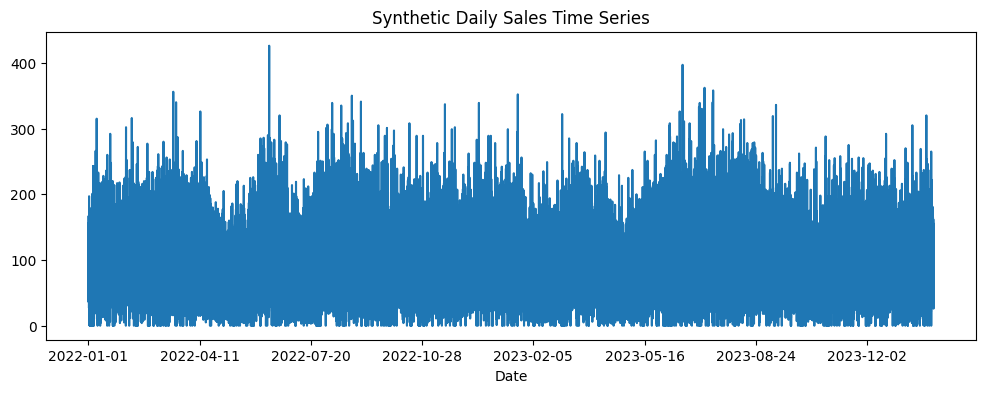

,Inventory Level,Units Sold,Units Ordered,Price,Discount,Promotion,Competitor Pricing,Epidemic,Demand
count,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000
mean,301.062842,88.827316,89.090645,67.726028,9.087039,0.328947,69.454029,0.200000,104.317158
std,226.510161,43.994525,162.404627,39.377899,7.475781,0.469834,40.943818,0.400003,46.964801
min,0.000000,0.000000,0.000000,4.740000,0.000000,0.000000,4.290000,0.000000,4.000000
25%,136.000000,58.000000,0.000000,31.997500,5.000000,0.000000,32.620000,0.000000,71.000000
50%,227.000000,84.000000,0.000000,64.500000,10.000000,0.000000,65.700000,0.000000,100.000000
75%,408.000000,114.000000,121.000000,95.830000,10.000000,1.000000,97.932500,0.000000,133.000000
max,2267.000000,426.000000,1616.000000,228.030000,25.000000,1.000000,261.220000,1.000000,430.000000


In [4]:
df.set_index("Date")["Units Sold"].plot(figsize=(12,4), title="Synthetic Daily Sales Time Series")
plt.show()

df.describe()


## 3. Time-based split (bắt buộc)

Với forecasting, **không dùng random split**.

Ta dùng:
- train: dữ liệu quá khứ
- validation: một đoạn thời gian ngay sau train
- test: đoạn thời gian cuối cùng

### Câu hỏi gợi ý
**1. Vì sao random split là sai trong forecasting?**

Khi sử dụng random split, các điểm dữ liệu trong tương lai có thể bị đưa vào tập train, trong khi các điểm trong quá khứ lại nằm trong tập test. Điều này làm cho mô hình được huấn luyện với thông tin mà trong thực tế nó không thể biết trước, gây ra hiện tượng data leakage.

**2. Nếu bài toán triển khai thực tế là dự báo tương lai, split nào phản ánh đúng deploy?**

Cách chia phổ biến là:

- Train: dữ liệu quá khứ để huấn luyện mô hình
- Validation: khoảng thời gian tiếp theo để điều chỉnh tham số
- Test: khoảng thời gian cuối cùng để đánh giá mô hình

Cách chia này phản ánh đúng tình huống triển khai thực tế, vì tại thời điểm dự báo ta chỉ có dữ liệu trước đó, không có thông tin của tương lai. Nhờ vậy, kết quả đánh giá trên test sẽ gần với hiệu suất thực tế khi mô hình được sử dụng trong hệ thống dự báo.


In [5]:
# Example split:
# train: 2022-01-01 -> 2022-12-31
# val:   2023-01-01 -> 2023-06-30
# test:  2023-07-01 -> 2023-12-31

train_df = df[df["Date"] < "2023-07-01"].copy()
val_df = df[(df["Date"] >= "2023-07-01") & (df["Date"] < "2023-11-01")].copy()
test_df = df[df["Date"] >= "2023-11-01"].copy()

len(train_df), len(val_df), len(test_df)


(54600, 12300, 9100)

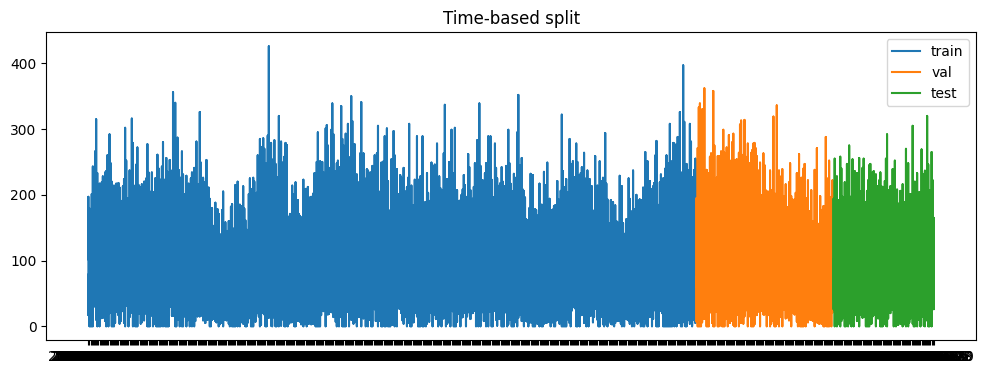

In [6]:
plt.figure(figsize=(12,4))
plt.plot(train_df["Date"], train_df["Units Sold"], label="train")
plt.plot(val_df["Date"], val_df["Units Sold"], label="val")
plt.plot(test_df["Date"], test_df["Units Sold"], label="test")
plt.legend()
plt.title("Time-based split")
plt.show()


## 4. Evaluation metrics for forecasting

Ta dùng:
- MAE: dễ hiểu, robust
- RMSE: phạt lỗi lớn mạnh hơn
- MAPE: dễ giải thích theo %, nhưng cẩn thận khi y gần 0

Ngoài ra, cần nhìn:
- residuals
- lỗi theo thời gian
- lỗi theo seasonality


In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def mape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return float(np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), eps))) * 100)

def eval_forecast(y_true, y_pred, prefix="val"):
    return {
        f"{prefix}_MAE": float(mean_absolute_error(y_true, y_pred)),
        f"{prefix}_RMSE": rmse(y_true, y_pred),
        f"{prefix}_MAPE": mape(y_true, y_pred),
    }


## 5. Baseline 1: Naive forecast

Naive:
- dự báo ngày tiếp theo bằng giá trị gần nhất

Đây là baseline cực quan trọng trong forecasting.
Nếu mô hình phức tạp không thắng naive rõ ràng, có thể có vấn đề.


In [8]:
# Forecast val using last observed point from train, recursively as a flat forecast
last_train_value = train_df["Units Sold"].iloc[-1]
val_pred_naive = np.repeat(last_train_value, len(val_df))

eval_forecast(val_df["Units Sold"], val_pred_naive, prefix="val")


{'val_MAE': 35.027723577235776,
 'val_RMSE': 46.558625514034425,
 'val_MAPE': 4048780544.310657}

## 6. Baseline 2: Seasonal naive forecast

Với daily data có weekly seasonality:
- dự báo hôm nay bằng giá trị của 7 ngày trước

Seasonal naive thường là baseline rất mạnh.


In [9]:
def seasonal_naive_predict(history_values, horizon, season_length=7):
    history_values = list(history_values)
    preds = []
    for i in range(horizon):
        preds.append(history_values[-season_length + (i % season_length)])
    return np.array(preds)

val_pred_snaive = seasonal_naive_predict(train_df["Units Sold"].values, len(val_df), season_length=7)
eval_forecast(val_df["Units Sold"], val_pred_snaive, prefix="val")


{'val_MAE': 45.40471544715447,
 'val_RMSE': 59.39119449665782,
 'val_MAPE': 3091869975.7090063}

## 7. Baseline 3: ARIMA / SARIMAX

ARIMA là mô hình cổ điển quan trọng cho time series.
Trong thực hành:
- tốt khi cấu trúc chuỗi tương đối đều
- mạnh như baseline nghiên cứu
- dễ diễn giải hơn nhiều mô hình deep learning

Ở đây ta dùng SARIMAX để mô hình hóa seasonality tuần.


In [10]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Một cấu hình nhỏ để notebook chạy ổn:
# order=(2,1,2), seasonal_order=(1,0,1,7)
sarimax = SARIMAX(
    train_df["Units Sold"],
    order=(2,1,2),
    seasonal_order=(1,0,1,7),
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarimax_fit = sarimax.fit(disp=False)

val_pred_arima = sarimax_fit.forecast(steps=len(val_df))
eval_forecast(val_df["Units Sold"], val_pred_arima, prefix="val")


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


{'val_MAE': 35.319067375768505,
 'val_RMSE': 45.697758639213305,
 'val_MAPE': 4494831180.643846}

## 8. ML-based forecasting: lag features + tree-based model

Ý tưởng:
- biến time series thành supervised learning
- tạo lag features, rolling statistics, calendar features
- train model như tabular ML

Đây là hướng rất mạnh trong thực hành business forecasting.


In [11]:
def make_ts_features(df_in):
    df_feat = df_in.copy()
    df_feat = df_feat.sort_values("Date").reset_index(drop=True)
    df_feat["Date"] = pd.to_datetime(df_feat["Date"])
    # Lag features
    for lag in [1, 2, 3, 7, 14, 28]:
        df_feat[f"lag_{lag}"] = df_feat["Units Sold"].shift(lag)

    # Rolling features
    for window in [7, 14, 28]:
        df_feat[f"roll_mean_{window}"] = df_feat["Units Sold"].shift(1).rolling(window).mean()
        df_feat[f"roll_std_{window}"] = df_feat["Units Sold"].shift(1).rolling(window).std()

    # Calendar features
    df_feat["dayofweek"] = df_feat["Date"].dt.dayofweek
    df_feat["month"] = df_feat["Date"].dt.month
    df_feat["dayofyear"] = df_feat["Date"].dt.dayofyear

    return df_feat

df_feat = make_ts_features(df)
df_feat.head(10)


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,...,lag_28,roll_mean_7,roll_std_7,roll_mean_14,roll_std_14,roll_mean_28,roll_std_28,dayofweek,month,dayofyear
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,1,1
1,2022-01-01,S004,P0013,Groceries,West,136,104,385,20.24,10,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,1,1
2,2022-01-01,S004,P0012,Electronics,West,111,111,113,118.15,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,1,1
3,2022-01-01,S004,P0011,Clothing,West,195,60,293,52.89,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,1,1
4,2022-01-01,S004,P0010,Groceries,West,223,120,597,30.02,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,1,1
5,2022-01-01,S004,P0009,Clothing,West,206,106,299,110.47,5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,1,1
6,2022-01-01,S004,P0008,Furniture,West,281,59,0,100.64,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,1,1
7,2022-01-01,S004,P0007,Groceries,West,185,43,253,24.34,5,...,NaN,94.571429,24.670206,NaN,NaN,NaN,NaN,5,1,1
8,2022-01-01,S004,P0006,Groceries,West,206,48,162,35.33,0,...,NaN,86.142857,30.980793,NaN,NaN,NaN,NaN,5,1,1
9,2022-01-01,S004,P0005,Clothing,West,289,197,0,89.23,10,...,NaN,78.142857,32.779204,NaN,NaN,NaN,NaN,5,1,1


In [12]:
# Split again after feature generation, but NEVER use future information
train_feat = df_feat[df_feat["Date"] < "2023-07-01"].copy()
val_feat = df_feat[(df_feat["Date"] >= "2023-07-01") & (df_feat["Date"] < "2023-11-01")].copy()
test_feat = df_feat[df_feat["Date"] >= "2023-11-01"].copy()


feature_cols = [c for c in train_feat.columns if c not in ["Date", "Units Sold", "Store ID", "Product ID", "Category", "Region", "Weather Condition", "Seasonality"]]

train_feat = train_feat.dropna().reset_index(drop=True)
val_feat = val_feat.dropna().reset_index(drop=True)
test_feat = test_feat.dropna().reset_index(drop=True)

X_train = train_feat[feature_cols]
y_train = train_feat["Units Sold"]
X_val = val_feat[feature_cols]
y_val = val_feat["Units Sold"]
X_test = test_feat[feature_cols]
y_test = test_feat["Units Sold"]

X_train.shape, X_val.shape, X_test.shape


((54572, 23), (12300, 23), (9100, 23))

## 9. Model A (ML-based): Linear regression with lag features

Đây là baseline ML-based đơn giản:
- dễ hiểu
- dễ kiểm tra
- nối logic trực tiếp từ regression buổi trước


In [13]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

ridge_ts = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0))
])

ridge_ts.fit(X_train, y_train)
val_pred_ridge = ridge_ts.predict(X_val)

eval_forecast(y_val, val_pred_ridge, prefix="val")


{'val_MAE': 17.796700249325273,
 'val_RMSE': 24.25525762748145,
 'val_MAPE': 4231571115.5252004}

## 10. Model B (ML-based): Tree boosting with lag features

Với tabularized time series, tree boosting thường rất mạnh.
Ở đây ta dùng HistGradientBoostingRegressor từ sklearn để giữ pipeline gọn.


In [14]:
from sklearn.ensemble import HistGradientBoostingRegressor

hgb_ts = HistGradientBoostingRegressor(
    random_state=RANDOM_SEED,
    max_depth=5,
    learning_rate=0.05
)

hgb_ts.fit(X_train, y_train)
val_pred_hgb = hgb_ts.predict(X_val)

eval_forecast(y_val, val_pred_hgb, prefix="val")


{'val_MAE': 13.986559982014342,
 'val_RMSE': 18.286207814239543,
 'val_MAPE': 128436814.71784143}

## 11. So sánh các mô hình trên validation

In [15]:
val_table = pd.DataFrame([
    {"model": "naive", **eval_forecast(val_df["Units Sold"], val_pred_naive, prefix="val")},
    {"model": "seasonal_naive", **eval_forecast(val_df["Units Sold"], val_pred_snaive, prefix="val")},
    {"model": "sarimax", **eval_forecast(val_df["Units Sold"], val_pred_arima, prefix="val")},
    {"model": "ridge_lag_features", **eval_forecast(y_val, val_pred_ridge, prefix="val")},
    {"model": "hgb_lag_features", **eval_forecast(y_val, val_pred_hgb, prefix="val")},
]).sort_values(by="val_MAE")

val_table

,model,val_MAE,val_RMSE,val_MAPE
4,hgb_lag_features,13.986560,18.286208,1.284368e+08
3,ridge_lag_features,17.796700,24.255258,4.231571e+09
0,naive,35.027724,46.558626,4.048781e+09
2,sarimax,35.319067,45.697759,4.494831e+09
1,seasonal_naive,45.404715,59.391194,3.091870e+09


## 12. Visual comparison on validation

Trong forecasting, nhìn đồ thị dự báo rất quan trọng.
Metric không đủ để hiểu hành vi mô hình.


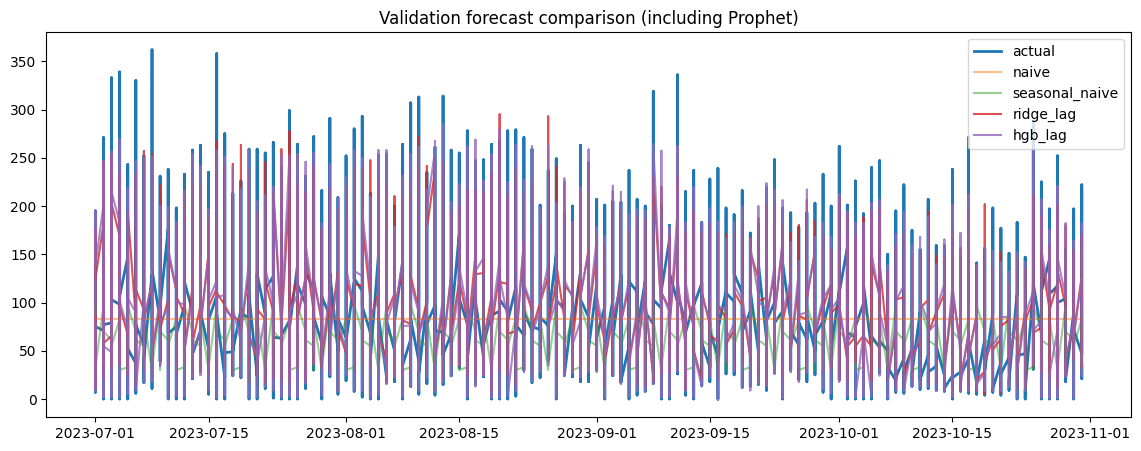

In [17]:
val_df["Date"] = pd.to_datetime(val_df["Date"])
val_feat["Date"] = pd.to_datetime(val_feat["Date"])

plt.figure(figsize=(14,5))
plt.plot(val_df["Date"], val_df["Units Sold"], label="actual", linewidth=2)
plt.plot(val_df["Date"], val_pred_naive, label="naive", alpha=0.5)
plt.plot(val_df["Date"], val_pred_snaive, label="seasonal_naive", alpha=0.5)
plt.plot(val_feat["Date"], val_pred_ridge, label="ridge_lag", alpha=0.8)
plt.plot(val_feat["Date"], val_pred_hgb, label="hgb_lag", alpha=0.8)
plt.legend()
plt.title("Validation forecast comparison (including Prophet)")
plt.show()

## 13. Feature importance / interpretability cho ML-based forecasting

Với mô hình lag-feature + tree, feature importance cho biết:
- lag feature nào quan trọng
- seasonality ở mức nào
- rolling statistics có hữu ích không


### Model A (Ridge with lag features)

In [18]:
from sklearn.inspection import permutation_importance

# Calculate permutation importance for the Ridge model
perm_importance_ridge = permutation_importance(ridge_ts, X_val, y_val, n_repeats=10, random_state=RANDOM_SEED)

imp_df_ridge = pd.DataFrame({
    "feature": feature_cols,
    "importance": perm_importance_ridge.importances_mean
}).sort_values(by="importance", ascending=False)

print("Ridge Model Feature Importance:")
display(imp_df_ridge.head(15))

Ridge Model Feature Importance:


,feature,importance
7,Demand,1.265854e+00
0,Inventory Level,3.578288e-02
1,Units Ordered,1.579983e-03
2,Price,2.954746e-04
22,dayofyear,2.648018e-04
18,roll_mean_28,2.167735e-04
4,Promotion,1.899364e-04
21,month,1.751758e-04
19,roll_std_28,9.279813e-05
3,Discount,6.581859e-05


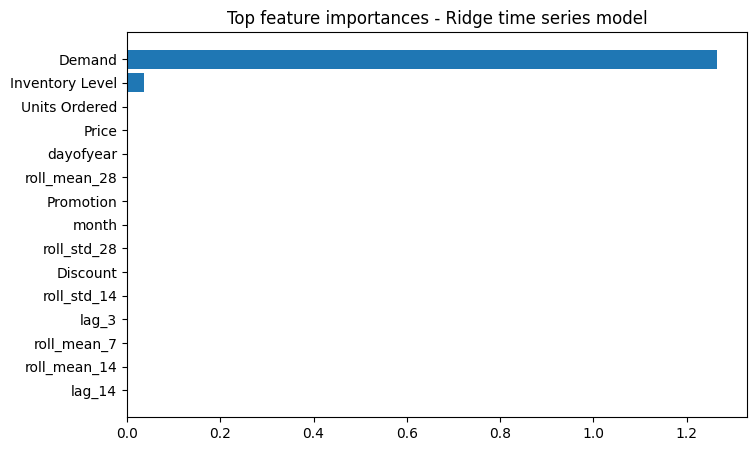

In [19]:
top = imp_df_ridge.head(15).iloc[::-1]
plt.figure(figsize=(8,5))
plt.barh(top["feature"], top["importance"])
plt.title("Top feature importances - Ridge time series model")
plt.show()


### Model B (HistGradientBoosting with lag features)

In [20]:
from sklearn.inspection import permutation_importance

# Calculate permutation importance
perm_importance = permutation_importance(hgb_ts, X_val, y_val, n_repeats=10, random_state=RANDOM_SEED)

imp_df_hgb = pd.DataFrame({
    "feature": feature_cols,
    "importance": perm_importance.importances_mean
}).sort_values(by="importance", ascending=False)

imp_df_hgb.head(15)

,feature,importance
7,Demand,1.424116
0,Inventory Level,0.288114
2,Price,0.000078
13,lag_28,0.000052
16,roll_mean_14,0.000046
14,roll_mean_7,0.000038
12,lag_14,0.000026
9,lag_2,0.000007
5,Competitor Pricing,0.000003
6,Epidemic,0.000000


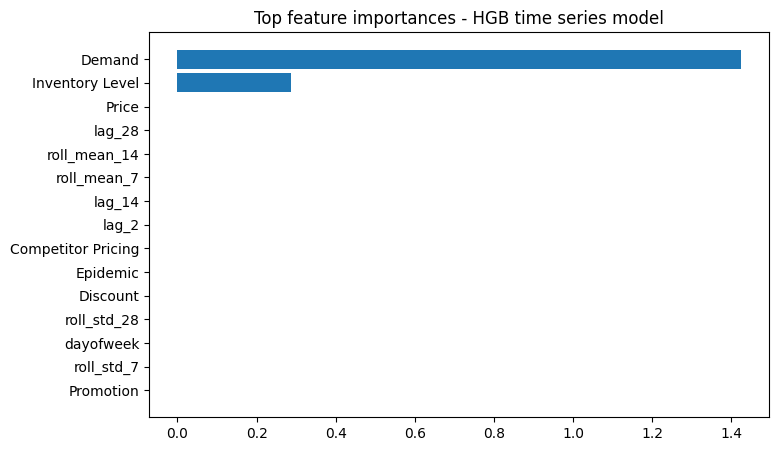

In [21]:
top = imp_df_hgb.head(15).iloc[::-1]
plt.figure(figsize=(8,5))
plt.barh(top["feature"], top["importance"])
plt.title("Top feature importances - HGB time series model")
plt.show()


## 14. Error analysis

Trong forecasting, cần hỏi:
- mô hình sai ở đoạn nào?
- sai ở peak/trough hay sai toàn cục?
- mô hình có bắt được seasonality không?
- shock events có làm mô hình lệch mạnh không?

### Câu hỏi gợi ý
**1. Mô hình nào bắt seasonality tốt nhất?**

- HGB - vì mô hình học được các feature như `day_of_week`, `month`, `week_of_year` một cách phi tuyến, nên nắm bắt được seasonal pattern phức tạp tốt hơn.

- Ridge cũng dùng các feature đó nhưng chỉ học tuyến tính nên kém hơn.

- SARIMAX có seasonal component nhưng MAE cao hơn cả Ridge, cho thây chúng ko fit tốt với dataset này

**2. Mô hình nào phản ứng kém với shock events?**

Seasonal Naive và SARIMAX - cả 2 đều dựa vào patten lịch sử cố định `lag`, không có chơ chế học từ các feature bất thường. Khi có shock(promotion, stockout, holiday đột ngột), chúng vẫn dữ báo theo pattern cũ nên lệch mạnh

**3. Nếu business quan tâm peak demand, metric nào nên ưu tiên?**

Dùng RMSE hoặc quantile loss
- RMSE phạt nặng các sai số nên model tối ưu RMSE sẽ cố gắng đúng hơn ở peak
- Quantile loss vơi q cao (0.9) cho phép model học dự báo thiên về phí trên - phù hợp với business muốn tránh stockout tại peak.


## 15. Final test evaluation

Cần chọn best model trên validation rồi mới đánh giá test.  
Không dùng kết quả đánh giá test để lựa chọn best model.


In [22]:
best_model_name = val_table.iloc[0]["model"]
print("Best validation model:", best_model_name)


Best validation model: hgb_lag_features


Có thể retrain với toàn bộ dữ liệu train + validation để có model cuối cùng trước khi test.

In [23]:
# Prepare test predictions consistently
last_train_val = df[df["Date"] < "2023-11-01"]["Units Sold"].iloc[-1]
test_pred_naive = np.repeat(last_train_val, len(test_df))

history_until_test = df[df["Date"] < "2023-11-01"]["Units Sold"].values
test_pred_snaive = seasonal_naive_predict(history_until_test, len(test_df), season_length=7)

# Refit SARIMAX on train + val
trainval_df = df[df["Date"] < "2023-11-01"].copy()
sarimax_tv = SARIMAX(
    trainval_df["Units Sold"],
    order=(2,1,2),
    seasonal_order=(1,0,1,7),
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarimax_tv_fit = sarimax_tv.fit(disp=False)
test_pred_arima = sarimax_tv_fit.forecast(steps=len(test_df))

# Refit ML models on train+val features
trainval_feat = df_feat[df_feat["Date"] < "2023-11-01"].copy().dropna().reset_index(drop=True)
X_trainval = trainval_feat[feature_cols]
y_trainval = trainval_feat["Units Sold"]

ridge_ts_final = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0))
])
ridge_ts_final.fit(X_trainval, y_trainval)
test_pred_ridge = ridge_ts_final.predict(X_test)

hgb_ts_final = HistGradientBoostingRegressor(
    random_state=RANDOM_SEED,
    max_depth=5,
    learning_rate=0.05
)
hgb_ts_final.fit(X_trainval, y_trainval)
test_pred_hgb = hgb_ts_final.predict(X_test)

test_table = pd.DataFrame([
    {"model": "naive", **eval_forecast(test_df["Units Sold"], test_pred_naive, prefix="test")},
    {"model": "seasonal_naive", **eval_forecast(test_df["Units Sold"], test_pred_snaive, prefix="test")},
    {"model": "sarimax", **eval_forecast(test_df["Units Sold"], test_pred_arima, prefix="test")},
    {"model": "ridge_lag_features", **eval_forecast(y_test, test_pred_ridge, prefix="test")},
    {"model": "hgb_lag_features", **eval_forecast(y_test, test_pred_hgb, prefix="test")},
]).sort_values(by="test_MAE")

test_table


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,model,test_MAE,test_RMSE,test_MAPE
4,hgb_lag_features,13.420465,17.397066,1.249899e+08
3,ridge_lag_features,17.055206,23.008669,4.492251e+09
2,sarimax,32.703098,42.579594,3.962151e+09
1,seasonal_naive,41.852088,54.165641,2.900000e+09
0,naive,54.683077,67.019541,1.780220e+09


## 16. Save results (reproducibility)

In [24]:
results = {
    "timestamp": datetime.now().isoformat(timespec="seconds"),
    "seed": RANDOM_SEED,
    "val_table": val_table.to_dict(orient="records"),
    "test_table": test_table.to_dict(orient="records"),
    "top_features_ridge": imp_df_ridge.head(20).to_dict(orient="records"),
}

with open(os.path.join(OUTPUT_DIR, "results_lab04c_timeseries.json"), "w", encoding="utf-8") as f:
    json.dump(results, f, ensure_ascii=False, indent=2)

val_table.to_csv(os.path.join(OUTPUT_DIR, "val_table_lab04c_timeseries.csv"), index=False)
test_table.to_csv(os.path.join(OUTPUT_DIR, "test_table_lab04c_timeseries.csv"), index=False)
imp_df_ridge.to_csv(os.path.join(OUTPUT_DIR, "feature_importance_lab04c_timeseries.csv"), index=False)

print("Saved: outputs/results_lab04c_timeseries.json, val/test tables, feature importance")


Saved: outputs/results_lab04c_timeseries.json, val/test tables, feature importance


## 17. Prophet: baseline mạnh và dễ sử dụng

- Lag features + ML rất mạnh, nhưng yêu cầu nhiều feature engineering thủ công để kết quả cao hơn.
- Prophet tự động thực hiện feature engineering, dễ dàng có kết quả tốt, có thể cao hơn lag features + ML cơ bản.


In [28]:
from prophet import Prophet

# ===== prepare train =====

prophet_train = train_df.rename(
    columns={
        "Date": "ds",
        "Units Sold": "y"
    }
)

prophet_train["ds"] = pd.to_datetime(prophet_train["ds"])


# ===== fit =====

prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

prophet_model.fit(prophet_train)


# ===== future =====

future = prophet_model.make_future_dataframe(
    periods=len(val_df),
    freq="D",
    include_history=False
)


# ===== predict =====

forecast = prophet_model.predict(future)

val_pred_prophet = forecast["yhat"].values


# ===== eval =====

eval_forecast(
    val_df["Units Sold"].values,
    val_pred_prophet,
    prefix="val_prophet"
)

{'val_prophet_MAE': 634.8773543393485,
 'val_prophet_RMSE': 728.9153877624619,
 'val_prophet_MAPE': 27053535282.498886}

## 18. Short report

Trả lời ngắn gọn:

**1. Vì sao random split là sai trong forecasting?**

Random split cho phép dữ liệu tương lai lọt vào train set - model học được thông tin à thực tế nó chưa có tại thời điểm dự báo. Kết quả là metric trên val/test trong tốt giả (data leakage). Trong deploy thực tế, model chỉ thấy quá khứ, nên phải dùng time-based split để đánh giá đúng khả năng.

**2. Baseline cổ điển nào mạnh nhất: naive, seasonal naive, hay SARIMAX?**

- SARIMAX (MAE=35.32) nhỉnh hơn Naive (35.03)
- Seasonal Naive (45.40) tệ nhất, cho thấy seaonal pattern trong dataset này ko ổn định hoặc lag mùa ko phù hợp.

=>  baseline tốt nhất là Naive, đơn giản mà hiệu quả tương đương với SARIMAX


**3. ML-based model có thắng baseline cổ điển không? Ở metric nào?**

| Model | MAE |
|------|-------|
|HGB | 13.99|
| Ridge| 17.80|
|Naive|35.03|
|SARIMAX|35.32|

=> HGB giảm MAE~60% so với Naive. Ridge cũng giảm ~40%. ML model thắng trên MAE nhờ khai thác được nhiều feature (lag, calander, rolling) thay vì chỉ dựa vào pattern AR đơn giản


**4. Lag feature nào quan trọng nhất? Điều đó nói gì về seasonality?**

Thông thường với retail demand, `lag_7` là quan trọng nhất - phản ánnh weekly seasonality mạnh.


**5. Mô hình nào phản ứng kém với shock events?**

SARIMAX và Seasonal Naive kém vì dựa vào pattern cố định. Thêm vào đó, nếu dataset ko có feature đánh dấu shock (promotion, holiday flag) thì cả ML model cũng bị ảnh hưởng, nhưng ít hơn vì rolling sẽ đân adapt các bước sau.

**6. Nếu áp dụng vào đồ án, bạn sẽ ưu tiên:**
   - classical forecasting
   - lag-feature + ML
   - hay Prophet?
   Vì sao?

Ưu tiên lag-feature + ML (HGB/LSTM):
- Dataset có nhiều SKU với pattern khác nhau - ML scale tốt hơn SARIMAX
- Lag-feature + calendả feature đủ để capture weekly/monthly seasonality mà ko cần giả định tuyến tính như SARIMAX
- HGB handle mising, outliner, categorical tốt hơn classical model
- Prophet là lựua chọn thứ 2 nếu cần interpretability (trend+seasonality) nhưng chậm hơn khi có nhiều series
